# Introduction

Logistics efficiency is vital for business success, but delivery delays remain a major challenge. Using AI and Big Data, companies can predict and reduce these delays. This project uses a real-world logistics dataset from Kaggle to analyze shipment data and build a machine learning model that predicts whether a delivery will be delayed. The aim is to improve operational planning and customer satisfaction through data-driven insights.




# Business Problem

Frequent delivery delays and unpredictable delivery performance increase costs and reduce customer satisfaction in e-commerce/logistics operations.

# Objective

Build a classification model to predict delivery outcome (`label`) for incoming orders so logistics managers can proactively re-route or prioritize shipments or take alternative aproach


**Importing required libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
#from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

# plotting defaults
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8,5)


In [2]:
df1=pd.read_csv("/Users/Subham/Desktop/data/jupiternotebook/business_project/data/delay.csv")
variabledescription=pd.read_csv("/Users/Subham/Desktop/data/jupiternotebook/business_project/data/variable_description.csv")

In [3]:
pip install scikit-learn==1.3.0 xgboost==1.7.6 joblib==1.3.2

  Using cached scikit-learn-1.3.0.tar.gz (7.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached xgboost-1.7.6-py3-none-macosx_12_0_arm64.whl.metadata (1.9 kB)
  Using cached joblib-1.3.2-py3-none-any.whl.metadata (5.4 kB)
Using cached xgboost-1.7.6-py3-none-macosx_12_0_arm64.whl (1.6 MB)
Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for scikit-learn (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [830 lines of output]
      Partial import of sklearn during the build process.
      clang: error: unsupported option '-fopenmp'
      /private/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/pip-install-ykml39ur/scikit-learn_850f6d44e730478e9e8420a9b6eefadc/sklearn/_build_utils/openmp_helpers.py:121: UserWarning:
      
                      ***********
                      * WARNING *
                    

# Data Understanding

This logistics dataset has 15549 and 41 Columns.
is a detailed insight into the process of order fulfillment and sales of an organization, the main goal of which is to provide the prediction of the results of delivery by relying on numerous factors that can be defined in terms of operations and customers. The table merges the customer demographics (for instance, the city and the segment of the customer), detailed financials of the orders (like sales, profit per order, and order item discount rate), product data (such as product name and category id) and transport factors (like the shipping method and shipping date). The most critical part of the data is the label column, which assigns the result of deliveries as early arrival (-1), on time (0), or late (1). Such a structure is suitable to use the dataset to create a classification model (such as a Decision Tree or a Random Forest) that will identify the factors that help the most to explain timely or delayed shipments and, therefore, the business will be able to optimize its supply chain and make customers happier.


In [4]:
print("Columns:", df1.columns.tolist())

print(df1.shape)

Columns: ['payment_type', 'profit_per_order', 'sales_per_customer', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total_amount', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_category_id', 'product_name', 'product_price', 'shipping_date', 'shipping_mode', 'label']
(15549, 41)


In [5]:
print(variabledescription)

               variable_name         type  \
0               payment_type  categorical   
1           profit_per_order    numerical   
2         sales_per_customer    numerical   
3                category_id    numerical   
4              category_name         text   
5              customer_city  categorical   
6           customer_country  categorical   
7                customer_id    numerical   
8           customer_segment  categorical   
9             customer_state  categorical   
10          customer_zipcode         text   
11             department_id    numerical   
12           department_name         text   
13                  latitude    numerical   
14                 longitude    numerical   
15                    market  categorical   
16                order_city  categorical   
17             order_country  categorical   
18         order_customer_id    numerical   
19                order_date     datetime   
20                  order_id    numerical   
21    orde

**Distribution of major numerical columns** 

The main indicators of economic result of a shipment are the columns associated with Financial Metrics, i.e. profit per order, sales per customer, discount on order item, and profit on order. The spread of these values, especially the amount of profit and sales is critical to comprehend as an important input to predictive modeling (e.g., forecasting profit) or as the calculation of the key performance indicators (KPIs). To supplement the financial Metric, there is the Quantity/Volume Measurement namely order item quantity which determines the physical restrictions and resource allocation during the shipment, and therefore affects decisions regarding packaging, transportation capacity and final logistics cost.

In [6]:
numerical_columns=df1.select_dtypes(exclude='object').columns
numerical_columns

Index(['profit_per_order', 'sales_per_customer', 'category_id', 'customer_id',
       'customer_zipcode', 'department_id', 'latitude', 'longitude',
       'order_customer_id', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total_amount',
       'order_profit_per_order', 'product_card_id', 'product_category_id',
       'product_price', 'label'],
      dtype='object')

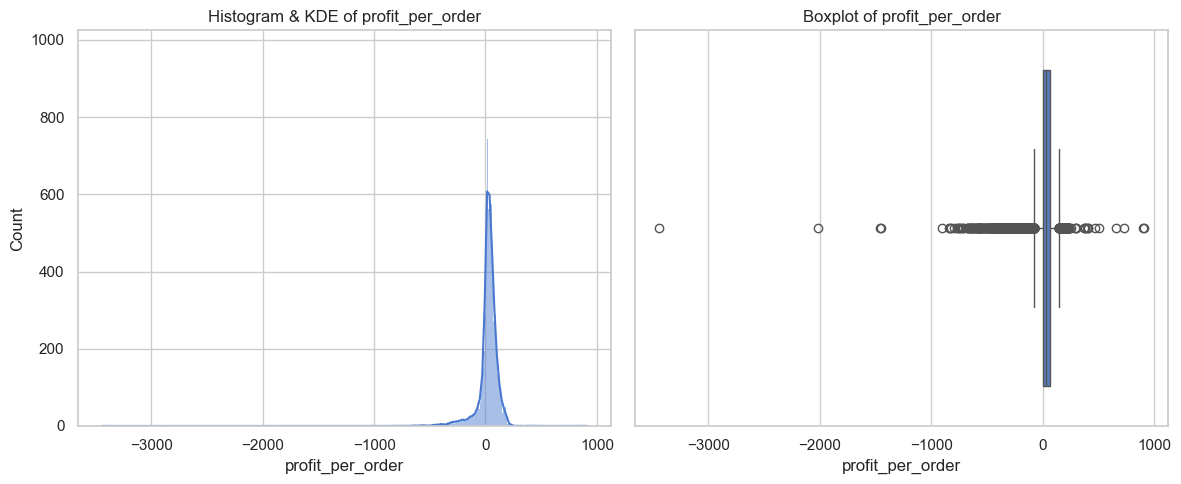

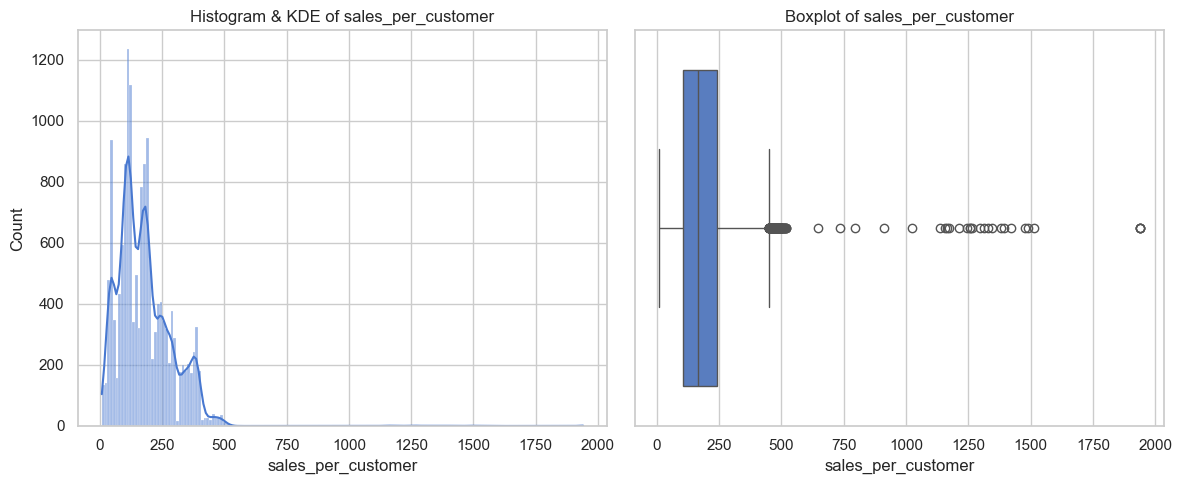

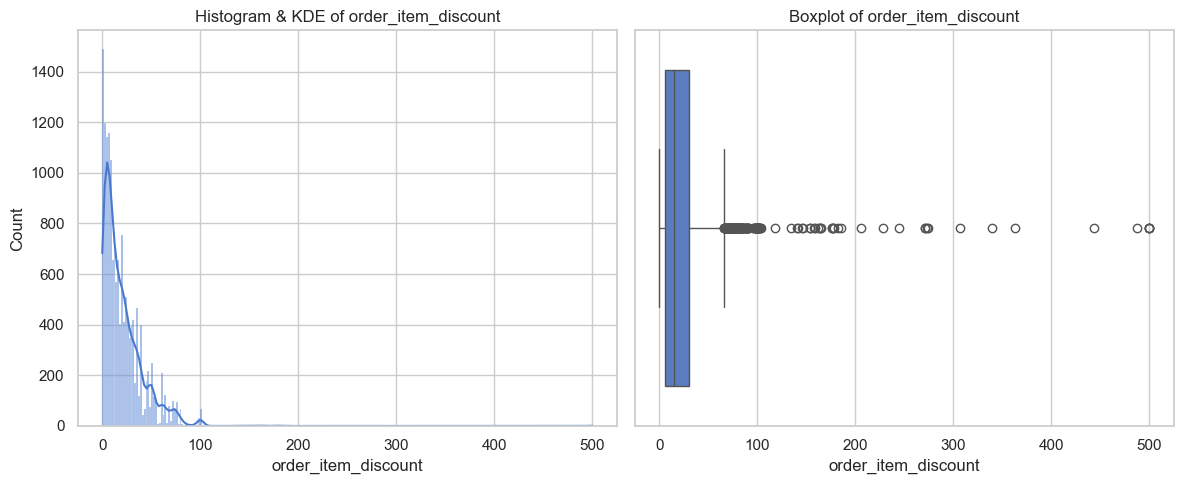

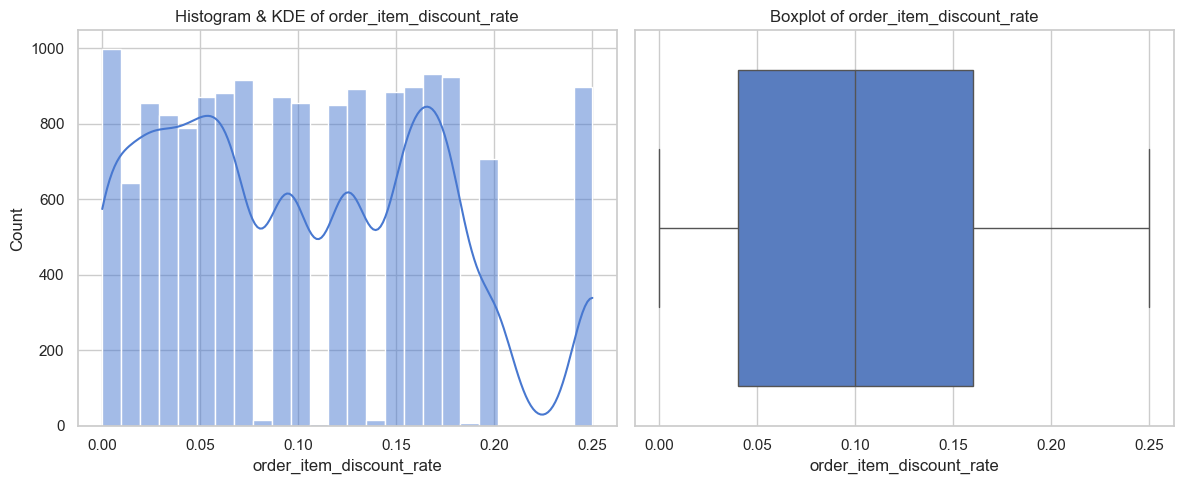

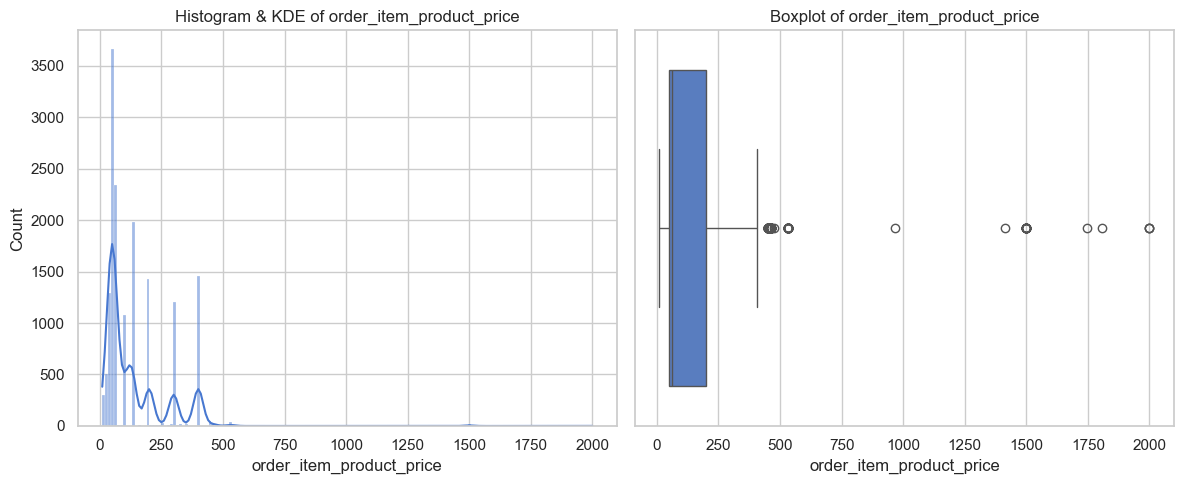

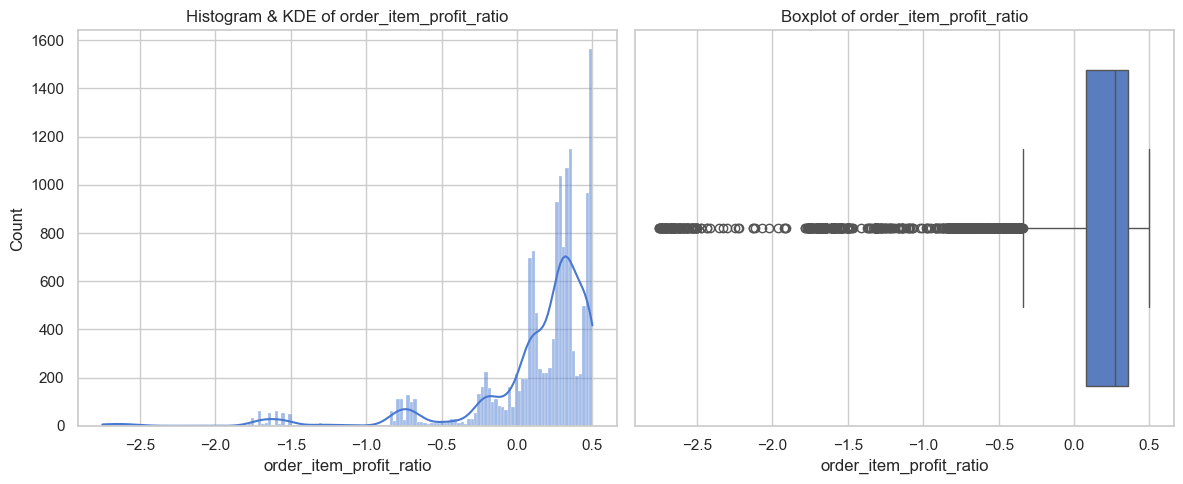

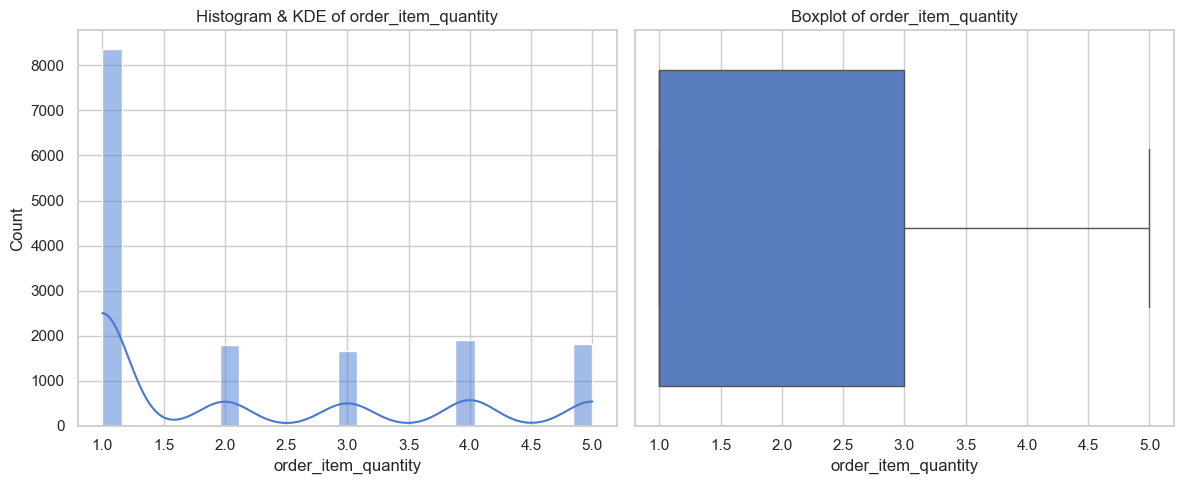

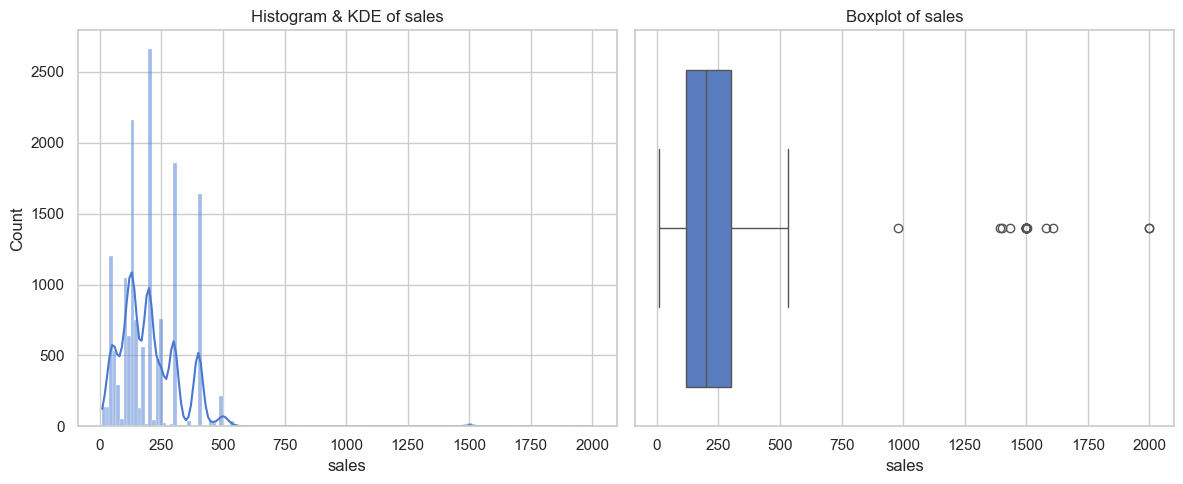

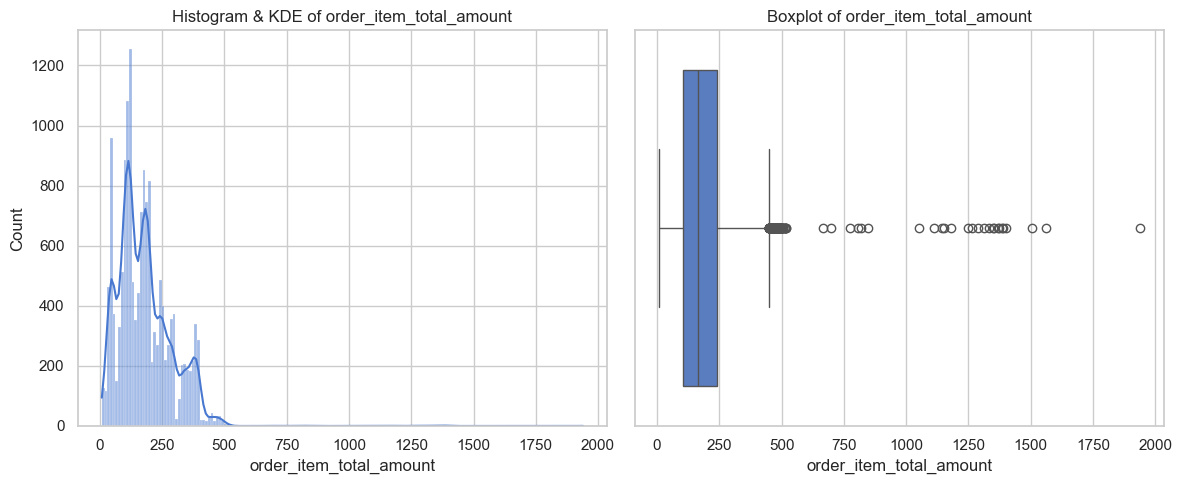

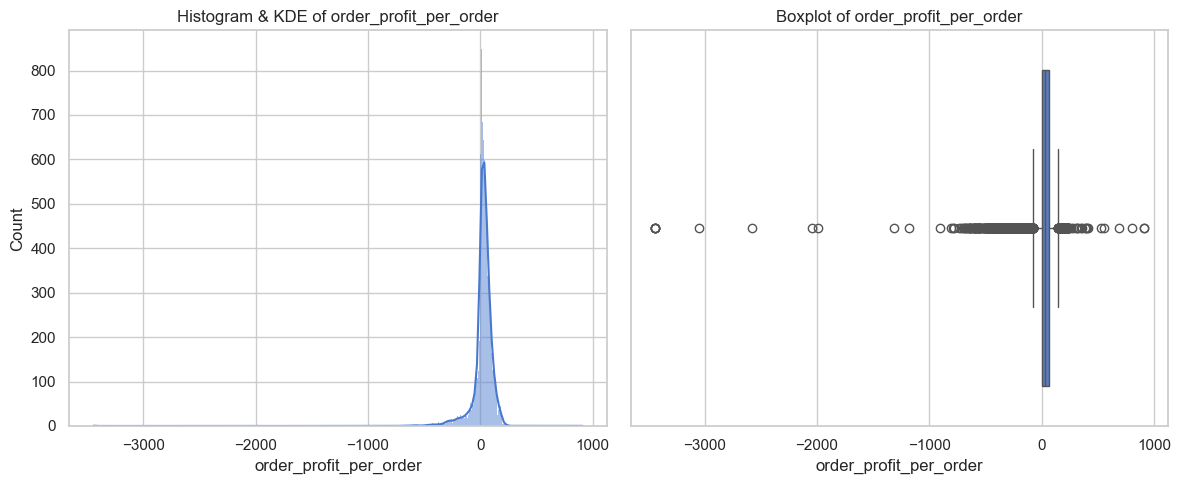

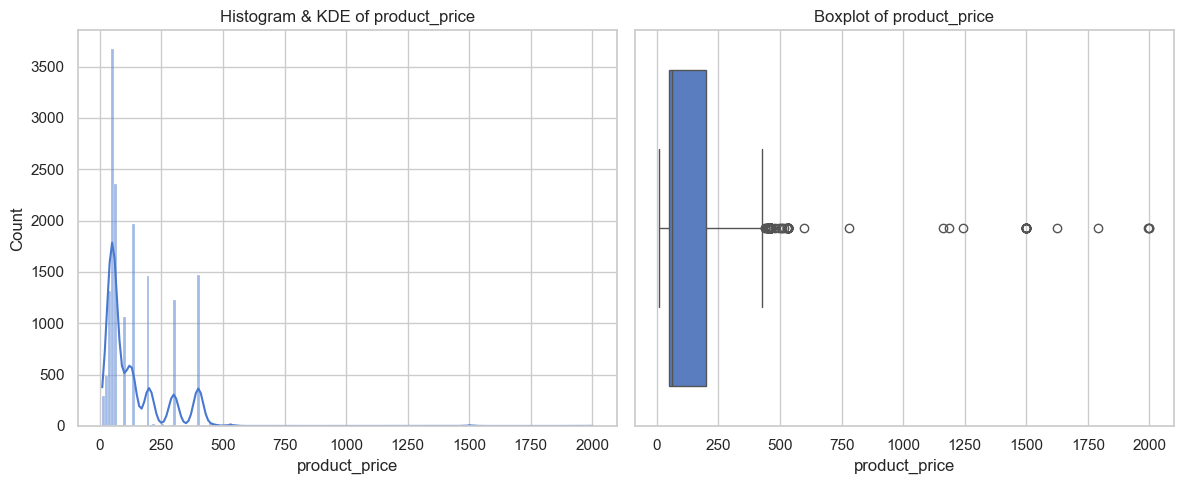

In [7]:
#only selecting major numerical coluns

major_numerical_col=['profit_per_order', 'sales_per_customer',
       'order_item_discount', 'order_item_discount_rate',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total_amount',
       'order_profit_per_order',
       'product_price']

for col in major_numerical_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram + KDE
    sns.histplot(df1[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram & KDE of {col}')

    # Boxplot
    sns.boxplot(x=df1[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [8]:
print("\nCounts of categorical columns (Top 10 values):")

cat_cols = df1.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df1[col].value_counts().head(10))



Counts of categorical columns (Top 10 values):

--- payment_type ---
payment_type
DEBIT       6148
PAYMENT     3849
TRANSFER    3796
CASH        1756
Name: count, dtype: int64

--- category_name ---
category_name
Cleats                  2212
Men's Footwear          1931
Women's Apparel         1906
Indoor/Outdoor Games    1657
Fishing                 1426
Water Sports            1391
Camping & Hiking        1127
Shop By Sport           1056
Cardio Equipment        1049
Electronics              219
Name: count, dtype: int64

--- customer_city ---
customer_city
Caguas          5964
Brooklyn         300
Chicago          277
Los Angeles      259
Bronx            147
Philadelphia      95
Honolulu          89
Houston           86
Dallas            86
Aurora            86
Name: count, dtype: int64

--- customer_country ---
customer_country
EE. UU.        9438
Puerto Rico    6111
Name: count, dtype: int64

--- customer_segment ---
customer_segment
Consumer       8332
Corporate      4603
Home 

**Visuals for some major categorical columns**

The annotated count plots display the distribution of orders across key categorical variables, with numeric labels showing the exact order count for each category. This visualization improves interpretability by allowing quick identification of dominant categories and operational concentration points within the dataset.

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/499461217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df1, palette='viridis')


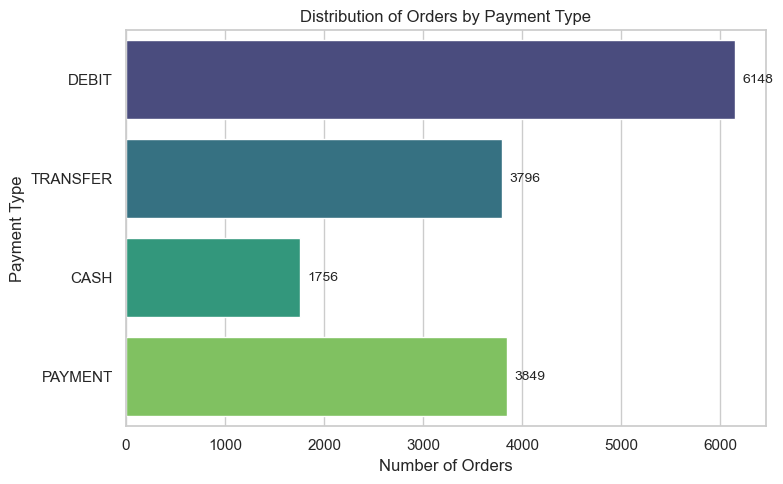

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/499461217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df1, palette='viridis')


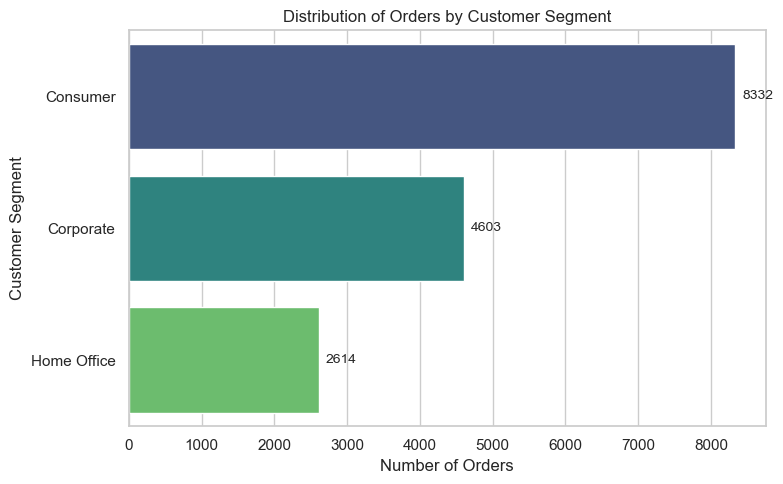

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/499461217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df1, palette='viridis')


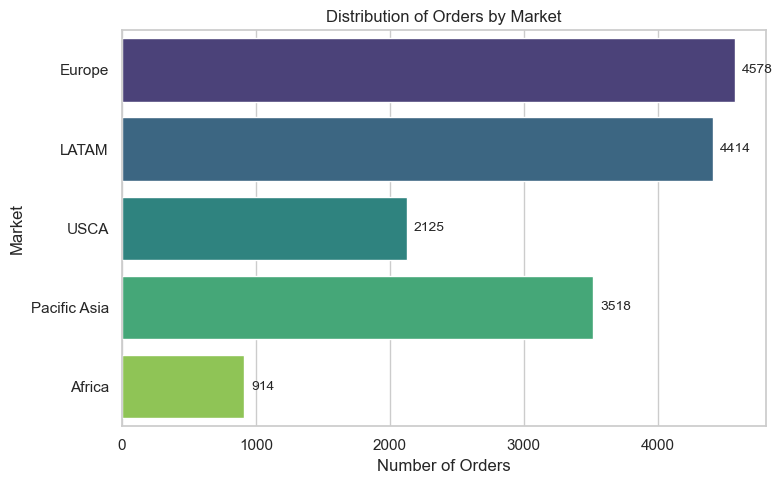

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/499461217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df1, palette='viridis')


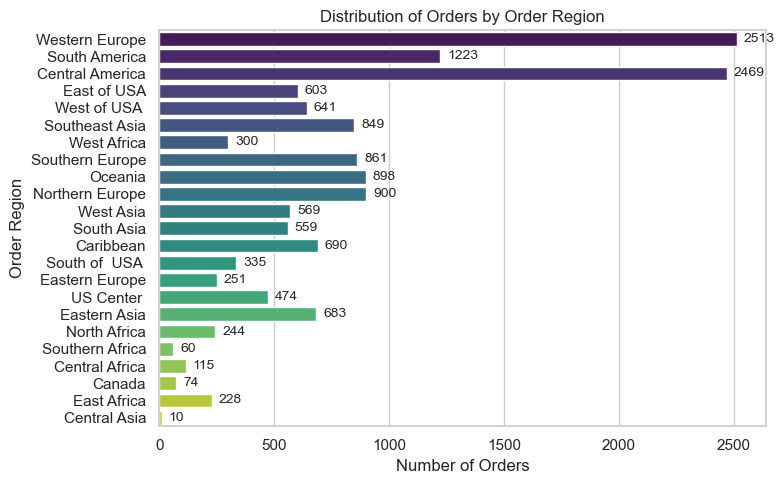

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/499461217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df1, palette='viridis')


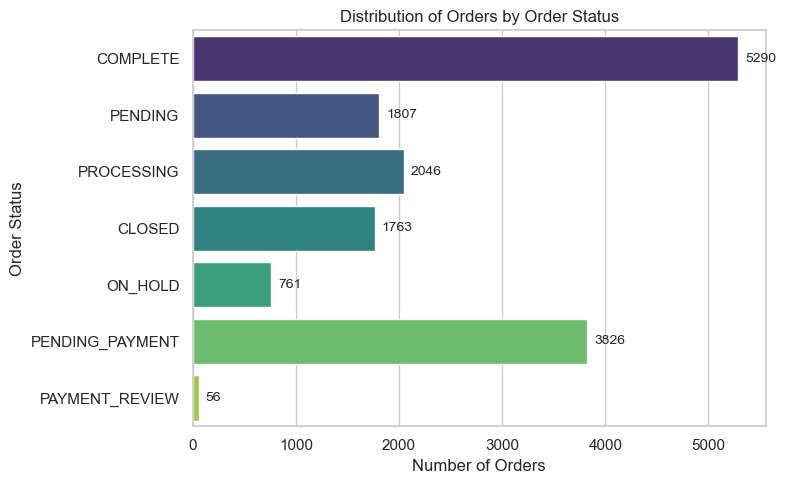

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/499461217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df1, palette='viridis')


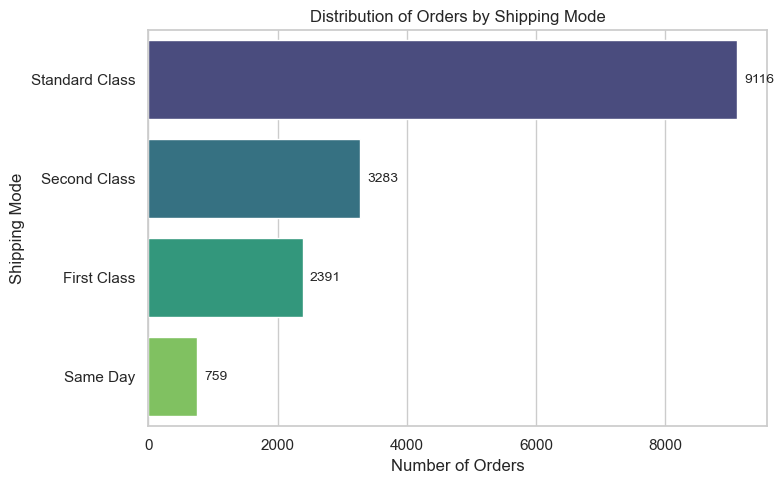

In [9]:
cols = ['payment_type','customer_segment','market',
        'order_region','order_status','shipping_mode']

for col in cols:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(y=col, data=df1, palette='viridis')
    
    # Add count labels
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f'{int(width)}',
            (width, p.get_y() + p.get_height() / 2),
            ha='left', va='center',
            fontsize=10,
            xytext=(5, 0),
            textcoords='offset points'
        )
    
    plt.title(f"Distribution of Orders by {col.replace('_', ' ').title()}")
    plt.xlabel("Number of Orders")
    plt.ylabel(col.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()


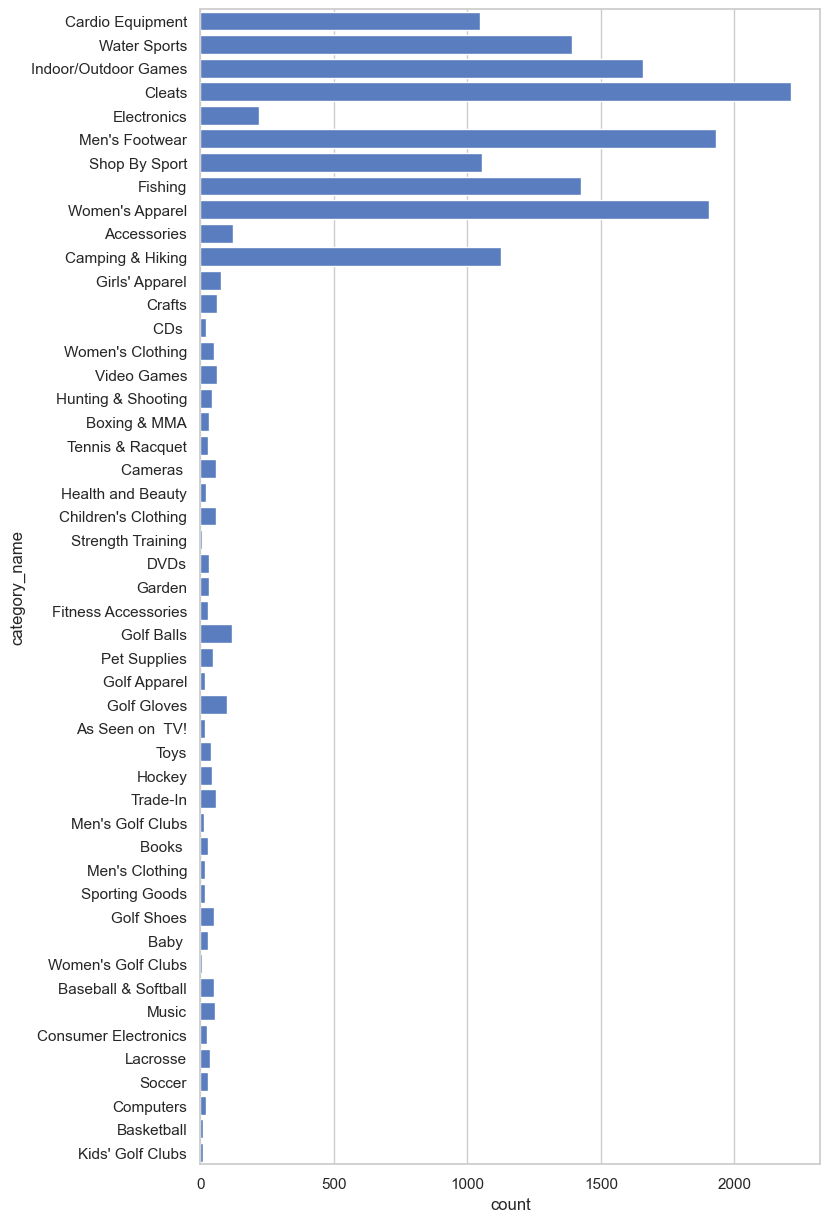

In [10]:
plt.figure(figsize=(8,15))
sns.countplot(y='category_name',data=df1)
plt.show()

The annotated count plots display the distribution of orders across key categorical variables, with numeric labels showing the exact order count for each category. This visualization improves interpretability by allowing quick identification of dominant categories and operational concentration points within the dataset.

# Understanding of the  the target (Label) variable

Markdown (explain):)
We saw a label column with values -1, 0, 1. We will create a binary delay_flag: 1 indicates delayed (label == -1), and 0 indicates not delayed (label == 0 or 1). Check class balance.

Original label value counts:


label
 1    8976
-1    3545
 0    3028
Name: count, dtype: int64


delay_flag distribution:


delay_flag
1    8976
0    6573
Name: count, dtype: int64

delay_flag
1    0.577272
0    0.422728
Name: proportion, dtype: float64

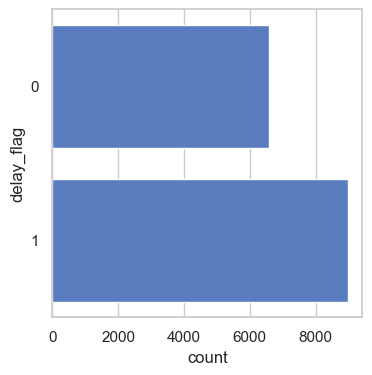

In [11]:
# Check original label distribution
print("Original label value counts:")
display(df1['label'].value_counts())


df1['delay_flag'] = df1['label'].apply(lambda x: 1 if x == 1 else 0)

# Check new target distribution
print("\ndelay_flag distribution:")
display(df1['delay_flag'].value_counts())
display(df1['delay_flag'].value_counts(normalize=True))

plt.figure(figsize=(4,4))
sns.countplot(y='delay_flag',data=df1)
plt.show()

# Data Cleaning

Check for missing values, duplicates, invalid datetimes, and fix datatypes (especially date columns). Drop or impute where appropriate.

In [12]:
missing = df1.isnull().sum().sort_values(ascending=False)
print(missing.head())


payment_type                0
order_region                0
order_item_discount_rate    0
order_item_id               0
order_item_product_price    0
dtype: int64


In [13]:
n_dup=df1.duplicated().sum() #it has no duplicate value


if n_dup > 0:
    df1 = df1.drop_duplicates()
    print("Dropped duplicate rows. New shape:", df1.shape)


In [14]:
# Convert date columns to datetime objects
df1["order_date"] = pd.to_datetime(df1["order_date"], utc=True).dt.tz_localize(None)
df1["shipping_date"] = pd.to_datetime(df1["shipping_date"], utc=True).dt.tz_localize(None)


In [15]:
# Ensure dates are proper datetime types
# Calculate delay in days and store it inside the dataframe
df1["shipping_delay_days"] = (df1["shipping_date"] - df1["order_date"]).dt.days

df1['shipping_delay_days'] = df1['shipping_delay_days'].astype(int)

# Check the new type
print(type(df1['shipping_delay_days']))

# Check that the new column is added
df1[["order_date", "shipping_date", "shipping_delay_days"]].head()



<class 'pandas.core.series.Series'>


,order_date,shipping_date,shipping_delay_days
0,2015-08-11 23:00:00,2015-08-12 23:00:00,1
1,2017-02-10 00:00:00,2017-04-08 23:00:00,57
2,2015-01-01 00:00:00,2015-03-18 00:00:00,76
3,2017-05-30 23:00:00,2017-03-18 00:00:00,-74
4,2015-03-28 00:00:00,2015-03-29 23:00:00,1


# Exploratory Data Analysis

# 1.Understand geographical and customer-based patterns.

**1 Which countries generate the most orders?**

Insight

The bar chart shows that the majority of orders are generated from the United States (EE. UU.), significantly outperforming other countries such as Puerto Rico. This indicates that the U.S. is the primary geographical market driving business volume, making it a critical region for logistics planning and performance optimization. Any delivery delays or operational inefficiencies in this market would have a disproportionately large impact on overall customer satisfaction and costs. In contrast, smaller markets contribute fewer orders and may require different logistics strategies. These insights highlight the importance of prioritizing resources, service levels, and delay-prevention measures in high-volume countries.

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/2888903429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_country.values, y=orders_by_country.index, palette="Blues_r")


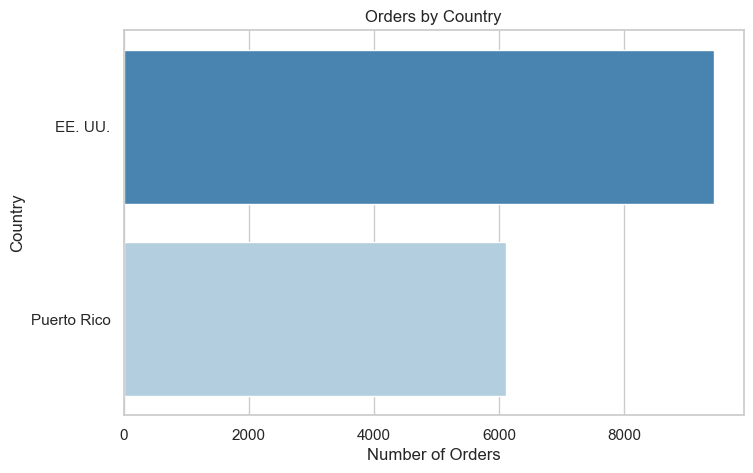

In [16]:
orders_by_country = df1["customer_country"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=orders_by_country.values, y=orders_by_country.index, palette="Blues_r")
plt.title("Orders by Country")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.show()


**2 Which customer segments dominate each country?**

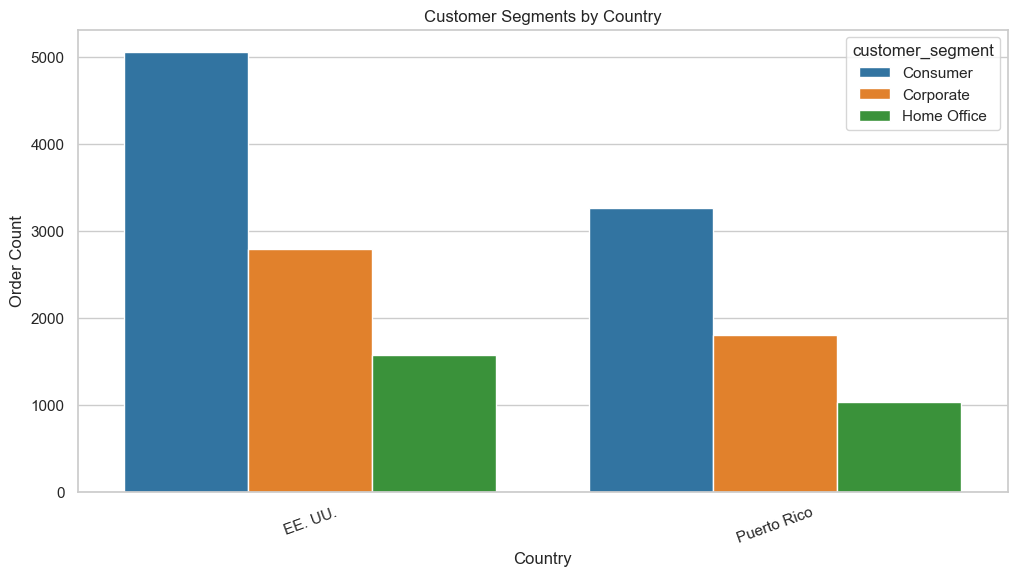

In [17]:
country_segment = df1.groupby(["customer_country", "customer_segment"])["customer_id"].count().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    data=country_segment,
    x="customer_country",
    y="customer_id",
    hue="customer_segment",
    palette="tab10"
)
plt.title("Customer Segments by Country")
plt.ylabel("Order Count")
plt.xlabel("Country")
plt.xticks(rotation=20)
plt.show()


**Interpretation**

we can clearly see "consumer" customer segment is strongest in each country — e.g., some countries may be dominated by Corporate customers, while others are mostly Consumer buyers.Understanding this distinction allows businesses to tailor marketing strategies, promotional activities, and inventory stocking based on the customer composition in each country. Countries with high Corporate demand may require dedicated B2B logistics and priority shipping, while Consumer-heavy nations may benefit from price discounts and more flexible delivery windows.

**3.Relationship between customer segment and order quantity**

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/940133273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


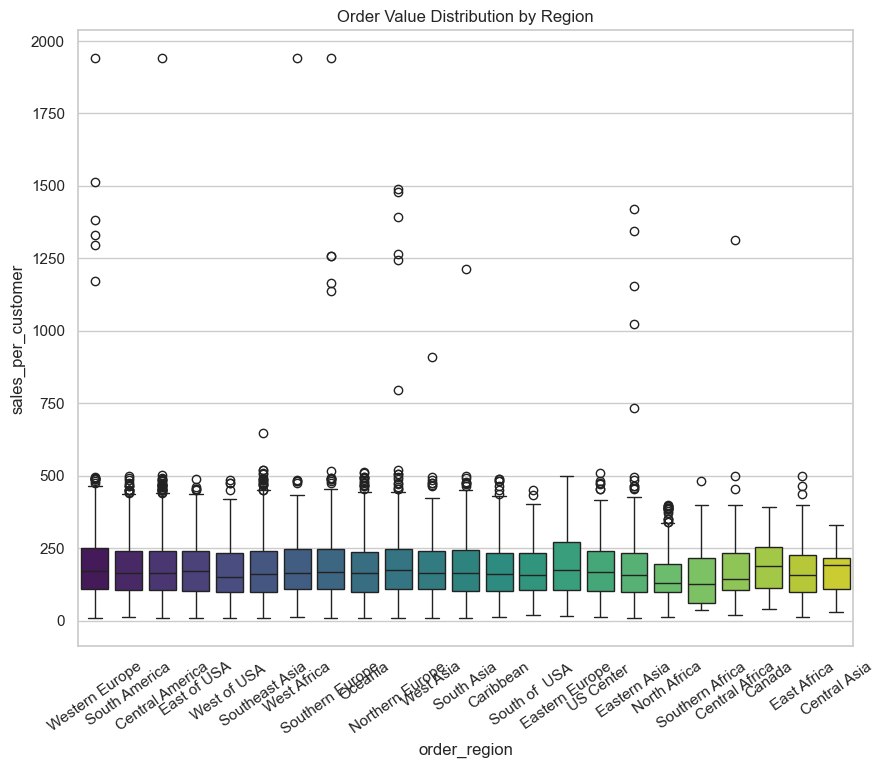

In [18]:
plt.figure(figsize=(10,8))
sns.boxplot(
    data=df1,
    x="order_region",
    y="sales_per_customer",
    palette="viridis"
)
plt.title("Order Value Distribution by Region")
plt.xticks(rotation=35)
plt.show()


**Interpretation**

This analysis highlights the purchasing patterns of different customer segments. Corporate customers often place larger orders due to business needs, whereas Consumer customers typically place smaller, need-based orders. This distinction has direct implications for logistics planning—Corporate shipments may require bulk handling, optimized packaging, and special delivery scheduling.

The insight also helps in inventory forecasting. Product demand from large-quantity buyers can significantly impact warehouse availability and replenishment cycles, making it crucial to anticipate their order patterns.

## 2.Product Analysis

**2.1 Which product categories are preferred by different customer segments?**


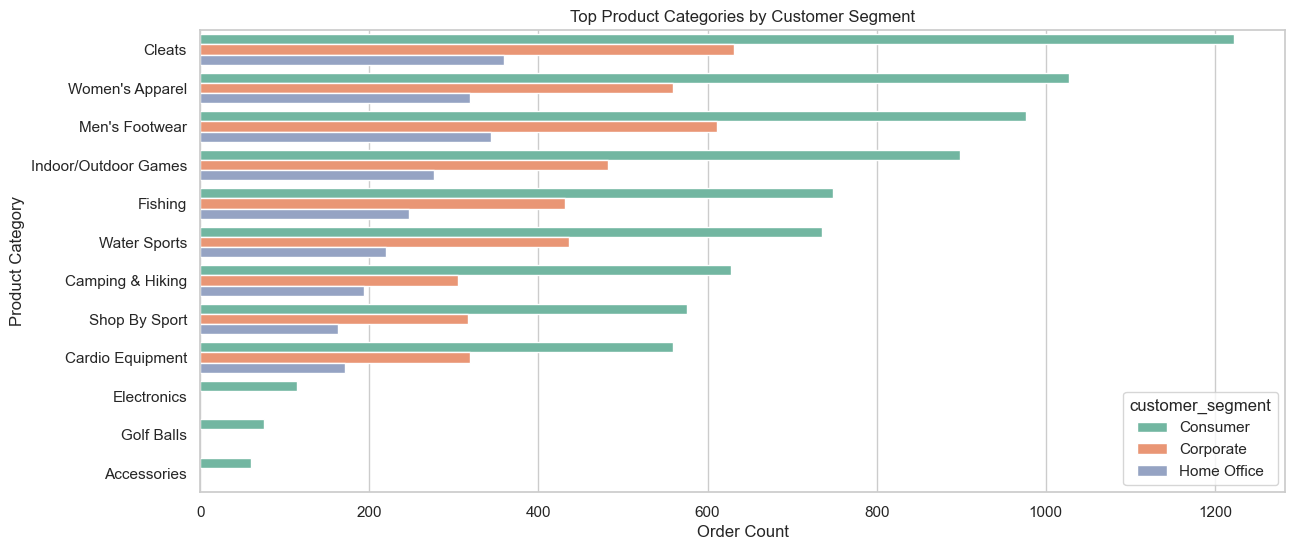

In [19]:
cat_segment = df1.groupby(["customer_segment", "category_name"])["order_id"].count().reset_index()
cat_segment
plt.figure(figsize=(14,6))
sns.barplot(
    data=cat_segment.sort_values("order_id", ascending=False).head(30),
    x="order_id",
    y="category_name",
    hue="customer_segment",
    palette="Set2"
)
plt.title("Top Product Categories by Customer Segment")
plt.xlabel("Order Count")
plt.ylabel("Product Category")
plt.show()


**Interpretation**

This analysis reveals which customer groups prefer specific categories, providing actionable information for targeted sales strategies. If Corporate customers tend to purchase items like office supplies in high volumes, whereas Consumers gravitate towards lifestyle or personal-use categories, the business can tailor advertising campaigns accordingly.

Additionally, identifying the overlap or gaps between segment behaviors allows the company to diversify product offerings, identify cross-selling opportunities, and optimize category-specific stocking strategies.

**2.2 Which products generate repeated large orders?**

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/2018610918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=bulk_products.index, x=bulk_products.values, palette="coolwarm")


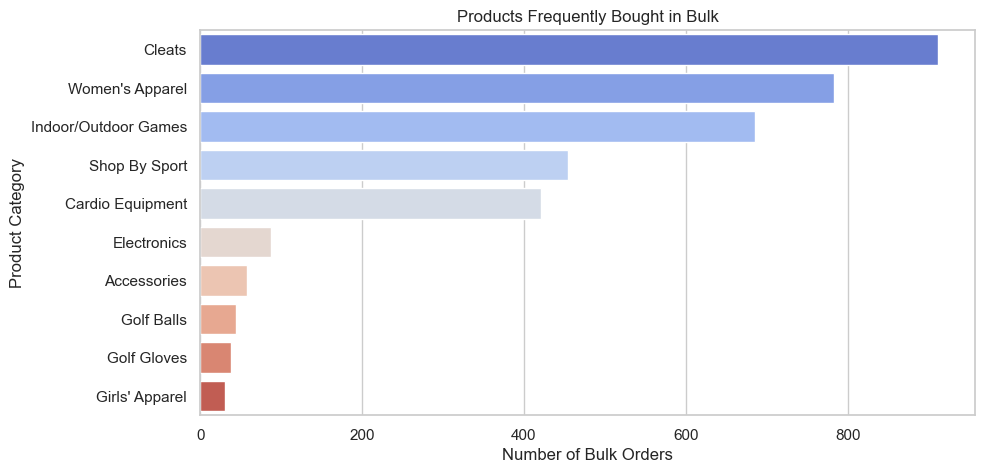

In [20]:
bulk_products = (
    df1[df1["order_item_quantity"] > 3].groupby("category_name")["order_item_quantity"].count().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,5))
sns.barplot(y=bulk_products.index, x=bulk_products.values, palette="coolwarm")
plt.title("Products Frequently Bought in Bulk")
plt.xlabel("Number of Bulk Orders")
plt.ylabel("Product Category")
plt.show()


**Interpretation**

By isolating products frequently bought in bulk, this analysis identifies categories that drive large operational loads. These products may require special packaging, pallet-based handling, or dedicated warehouse space.

Bulk-order categories are critical for forecasting peak-season demands, as they may heavily influence storage costs, shipping capacities, and replenishment cycles. Ensuring consistent supply for these categories can prevent stockouts and sustain customer satisfaction for high-volume buyers such as wholesalers or corporate clients.

# 3 Shipping Analysis

**3.1 Association between shipping mode and customer segment**


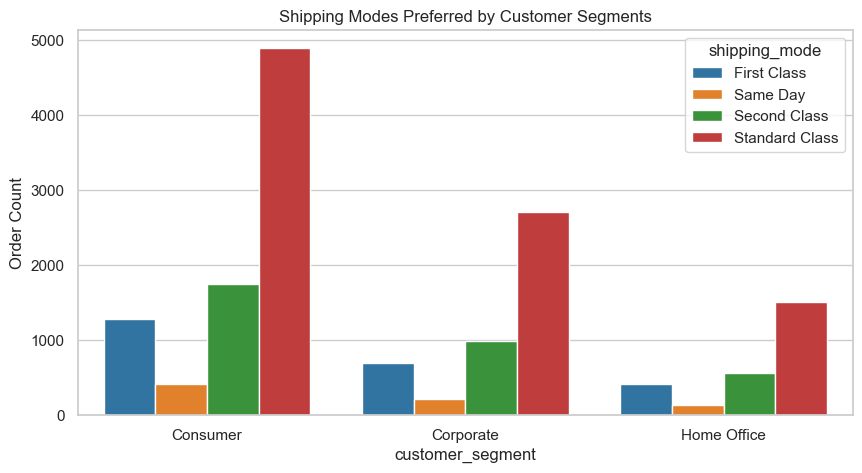

In [21]:
sgmt_spng = df1.groupby(["customer_segment", "shipping_mode"])["order_id"].count().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=sgmt_spng,
    x="customer_segment",
    y="order_id",
    hue="shipping_mode",
    palette="tab10"
)
plt.title("Shipping Modes Preferred by Customer Segments")
plt.ylabel("Order Count")
plt.show()


Different customer segments may prefer different shipping speeds and price points. Corporate customers may favor expedited shipping due to time-sensitive business needs, while Consumers may prioritize affordability over speed.

Understanding these preferences helps logistics teams allocate capacity more efficiently. It also enables the company to position different shipping options strategically—for example, promoting express delivery to high-value Corporate customers or offering economy plans to budget-conscious Consumers.

**q3.2 What are the Average Order Value by Shipping Mode**

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/2176706665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


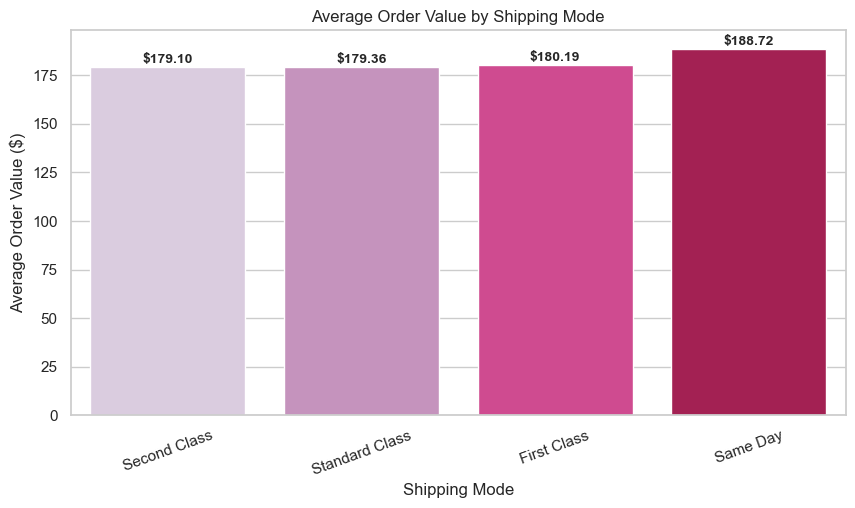

In [22]:
# Calculate mean sales per shipping mode
avg_value_by_ship = df1.groupby("shipping_mode")["sales_per_customer"].mean().sort_values()

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=avg_value_by_ship.index,
    y=avg_value_by_ship.values,
    palette="PuRd"
)

plt.title("Average Order Value by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Order Value ($)")
plt.xticks(rotation=20)

# Add values on top of bars
for i, v in enumerate(avg_value_by_ship.values):
    ax.text(i, v + 2, f"${v:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.show()


**Interpretation**

this insight supports strategic investments in the shipping modes that matter most to the business.

This comparison chart is crucial for aligning logistics resources with customer value, as it directly compares the average monetary value of orders against their corresponding shipping modes. High average order values in premium categories like "First Class" or "Same Day" indicate that customers placing large or urgent orders prioritize speed and reliability, confirming the need for priority processing and strict Service Level Agreement (SLA) adherence for these high-revenue shipments. Conversely, a lower average order value for "Standard Class" suggests this channel primarily serves price-sensitive consumers and cost-effective orders, making it the ideal target for cost-optimization efforts within the shipping strategy. This distinction allows the logistics team to efficiently allocate resources, ensuring that any potential delays in high-value shipping modes, which carry the highest financial risk, are rigorously managed.

# 4 Order Volume Analysis

**4.1 Number of Orders by Customer Segment**

The chart shows that the Consumer segment generates the highest number of orders, significantly exceeding Corporate and Home Office customers. This indicates that individual consumers are the primary drivers of order volume, making them a critical segment for logistics performance and delivery reliability. Corporate orders form the second-largest segment, likely representing fewer but potentially higher-value shipments, while Home Office customers contribute the smallest share. From a business perspective, delivery delays affecting the Consumer segment could have the greatest impact on overall customer satisfaction due to the high volume, whereas delays in Corporate orders may have contractual or service-level implications.

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_39347/3585995756.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


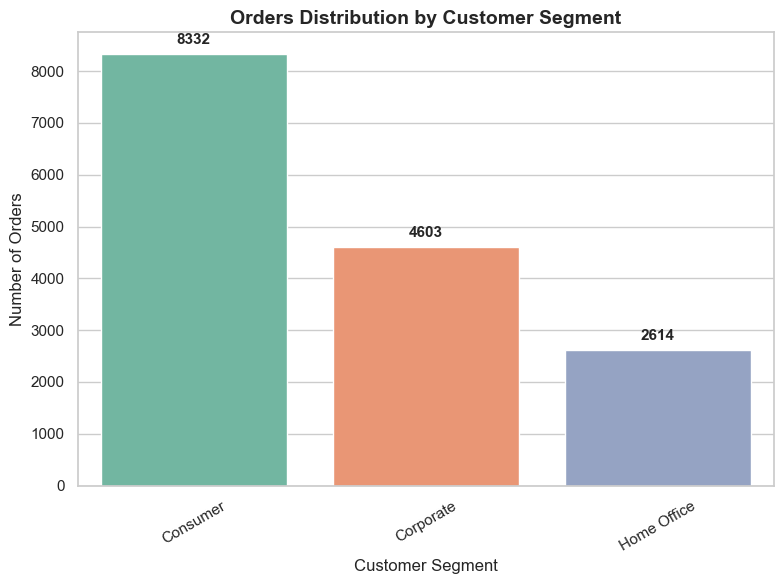

In [23]:
# Number of orders by customer segment
temp = df1['customer_segment'].value_counts()

plt.figure(figsize=(8, 6))
colors = sns.color_palette("Set2", len(temp))  # different color for each bar

ax = sns.barplot(
    x=temp.index,
    y=temp.values,
    palette=colors
)

# Annotate bars with counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.title("Orders Distribution by Customer Segment", fontsize=14, fontweight='bold')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**4.2 What are the moode of payment for each order**

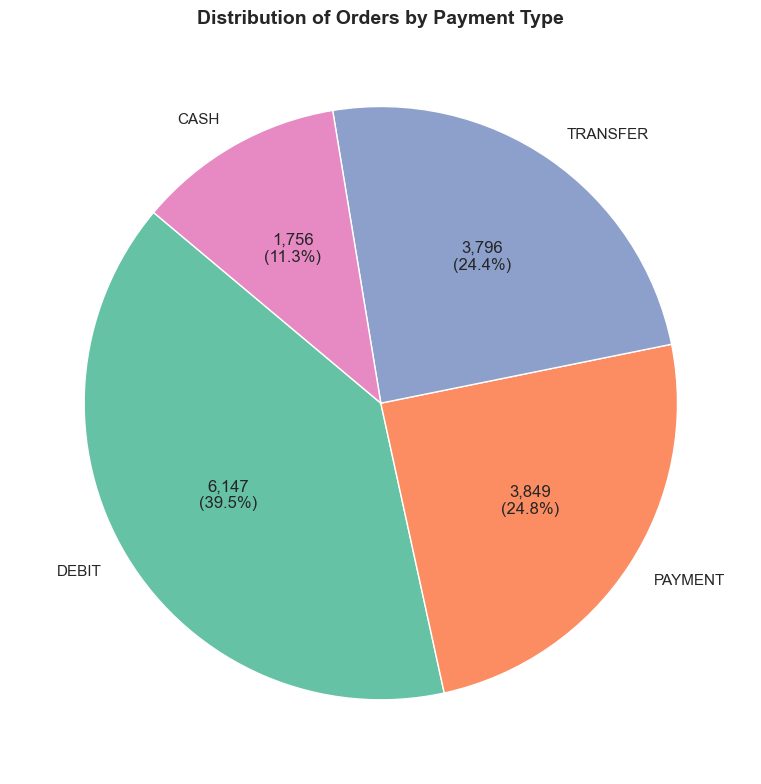

In [24]:
# Count payment types
temp = df1['payment_type'].value_counts().reset_index()
temp.columns = ['payment_type', 'count']  # rename columns

# Function for custom labels
def func(pct, allvalues):
    absolute = int(pct/100.*sum(allvalues))
    return f'{absolute:,}\n({pct:.1f}%)'

# Enhanced Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    x=temp['count'],
    labels=temp['payment_type'],
    autopct=lambda pct: func(pct, temp['count']),
    colors=sns.color_palette('Set2', len(temp)),  # beautiful multi-color palette
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.title("Distribution of Orders by Payment Type", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation**

The pie chart reveals the distribution of customer payment preferences across all orders.

The largest slice corresponds to the most frequently used payment method, showing that customers predominantly rely on this mode of payment.

Payment types with smaller slices indicate lower adoption and may represent:

Additional friction for customers (e.g., bank transfer, COD)

Longer processing times

Higher abandonment or failure rates

This insight is important because payment method choice influences order processing speed, which can ultimately affect delivery outcomes.

# 5.Delay Analysis

**5.1 What percentage of orders are delayed?**

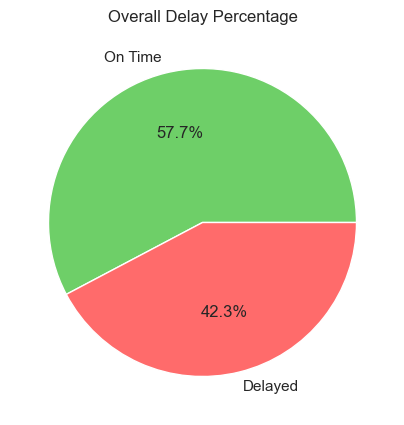

In [25]:
delay_counts = df1["delay_flag"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(delay_counts, labels=["On Time","Delayed"], autopct="%1.1f%%", colors=["#6ECF68","#FF6B6B"])
plt.title("Overall Delay Percentage")
plt.show()


**5.2 Delay rate by region and shipping mode**

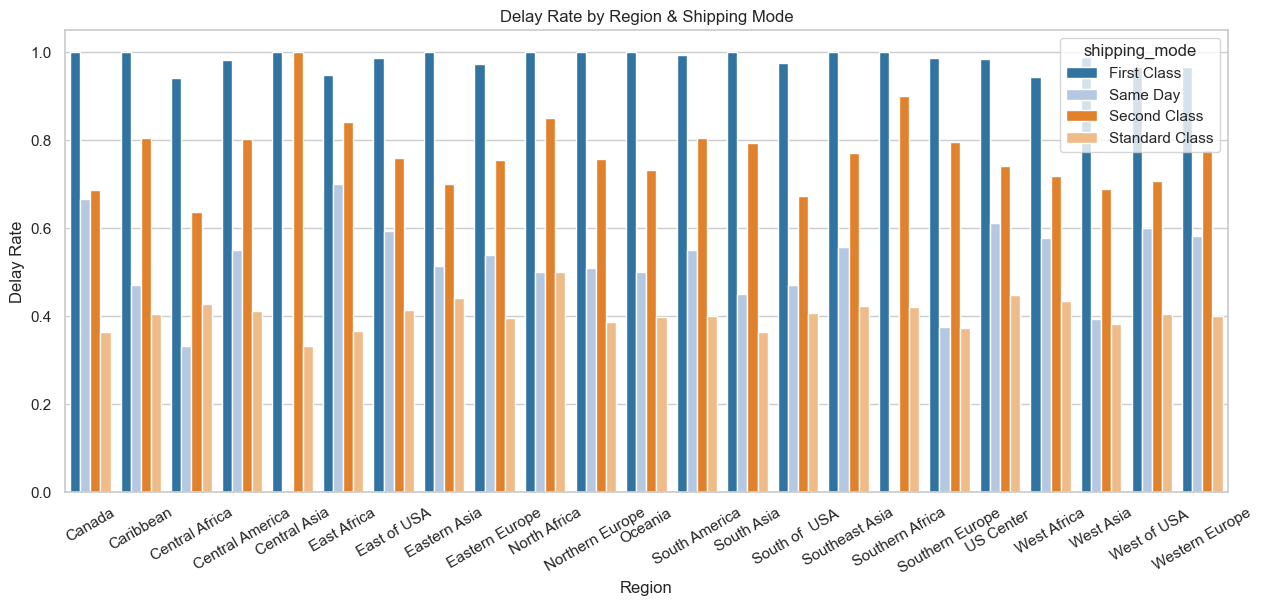

In [26]:
region_mode_delay = df1.groupby(["order_region", "shipping_mode"])["delay_flag"].mean().reset_index()

plt.figure(figsize=(15,6))
sns.barplot(
    data=region_mode_delay,
    x="order_region",
    y="delay_flag",
    hue="shipping_mode",
    palette="tab20"
)
plt.title("Delay Rate by Region & Shipping Mode")
plt.ylabel("Delay Rate")
plt.xlabel("Region")
plt.xticks(rotation=30)
plt.show()


**Impact Business Conclusion**

The analysis clearly shows that delivery performance is not only dependent on the shipping mode but also heavily influenced by region.
Premium services (First Class, Same Day) are consistently failing expectations, while Standard and Second-Class are more reliable.

This means:

The company should re-evaluate First-Class and Same-Day delivery promises, especially in developing regions.

Logistics partners in high-delay regions should be reviewed or replaced.

Pricing and service-level agreements (SLAs) for fast shipping need adjustment.

Future predictive modeling should include both region and shipping_mode as critical features because of their strong influence on delays.

**5.3 What proportion of delays that are within operational control (treatable) versus those caused by external or customer-side issues (non-treatable).?**

In [27]:

non_treatable_statuses = ["PENDING_PAYMENT", "On_Hold"]

treatable_delay = df1["order_status"].apply(
    lambda x: "Non-Treatable Delay" if x in non_treatable_statuses else "Treatable Delay"
)


In [28]:
treatable_counts = treatable_delay.value_counts(normalize=True) * 100

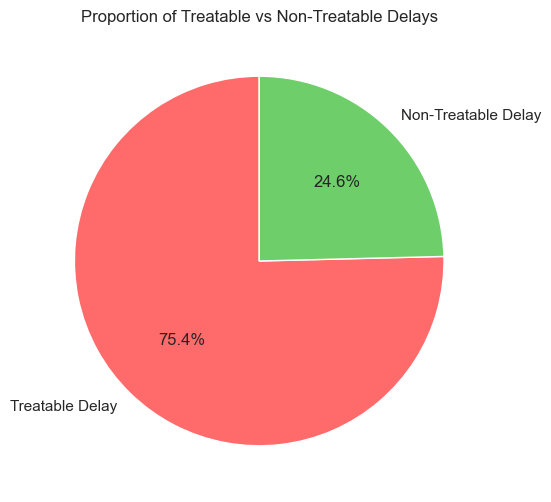

In [29]:
plt.figure(figsize=(6,6))
plt.pie(
    treatable_counts,
    labels=treatable_counts.index,
    autopct="%1.1f%%",
    colors=["#FF6B6B", "#6ECF6A"],
    startangle=90
)
plt.title("Proportion of Treatable vs Non-Treatable Delays")
plt.show()


**Interpretation**

The chart shows the proportion of delays that are within operational control (75.4%) versus those caused by external or customer-side issues (24.6%).

Treatable delays represent shipment delays due to logistics inefficiencies such as slow processing, routing issues, backlog, transportation delays, or failed SLA compliance. These are delays the company can reduce through operational improvements.

Non-treatable delays occur due to customer actions (e.g., late payment) or business conditions outside logistics control (e.g., orders on hold). These cannot be solved through shipping optimizations.

This breakdown is crucial because it helps the company understand how much of the delay problem can realistically be fixed using machine learning or process improvement, and how much is outside operational control.

# Model building

# 1.Data Preprocessing and Feature Engineering


**Reduce Cardinality of High-Cardinality Categorical Columns**

Some categorical columns have hundreds or thousands of unique values (cities, states, zip codes).
If we one-hot encode them, we will create too many columns, which:
Makes the model slow
Causes overfitting
Adds noise instead of learning
So we group rare categories into “Others”.
Categories that appear very few times do not contribute meaningful patterns.
They are grouped into a general category “Others” to reduce overfitting and improve model stability.

In [30]:
model_data = df1.copy()

# REDUCING CARDINALITY FOR CATEGORICAL VARIABLES
# (same logic as the original code)

# 1. customer_city
customer_city_count = model_data['customer_city'].value_counts()
city_less_50 = customer_city_count[customer_city_count < 50].index.tolist()
model_data['customer_city'] = model_data['customer_city'].apply(
    lambda x: 'Others' if x in city_less_50 else x
)

# 2. customer_state
customer_state_count = model_data['customer_state'].value_counts()
state_less_50 = customer_state_count[customer_state_count < 50].index.tolist()
model_data['customer_state'] = model_data['customer_state'].apply(
    lambda x: 'Others' if x in state_less_50 else x
)

# 3. order_city
order_city_count = model_data['order_city'].value_counts()
order_city_less_50 = order_city_count[order_city_count < 50].index.tolist()
model_data['order_city'] = model_data['order_city'].apply(
    lambda x: 'Others' if x in order_city_less_50 else x
)

# 4. order_country
order_country_count = model_data['order_country'].value_counts()
country_less_50 = order_country_count[order_country_count < 50].index.tolist()
model_data['order_country'] = model_data['order_country'].apply(
    lambda x: 'Others' if x in country_less_50 else x
)

# 5. order_region
order_region_count = model_data['order_region'].value_counts()
region_less_100 = order_region_count[order_region_count < 100].index.tolist()
model_data['order_region'] = model_data['order_region'].apply(
    lambda x: 'Others' if x in region_less_100 else x
)

# 6. order_state
order_state_count = model_data['order_state'].value_counts()
state_less_50 = order_state_count[order_state_count < 50].index.tolist()
model_data['order_state'] = model_data['order_state'].apply(
    lambda x: 'Others' if x in state_less_50 else x
)



In [31]:
#to see the changes 
categorical_cols=model_data.select_dtypes(include=['object'])
for cols in categorical_cols:
    print(model_data[cols].value_counts())
    print()

payment_type
DEBIT       6148
PAYMENT     3849
TRANSFER    3796
CASH        1756
Name: count, dtype: int64

category_name
Cleats                  2212
Men's Footwear          1931
Women's Apparel         1906
Indoor/Outdoor Games    1657
Fishing                 1426
Water Sports            1391
Camping & Hiking        1127
Shop By Sport           1056
Cardio Equipment        1049
Electronics              219
Accessories              123
Golf Balls               120
Golf Gloves              101
Girls' Apparel            76
Crafts                    63
Video Games               63
Children's Clothing       59
Trade-In                  58
Cameras                   57
Music                     55
Women's Clothing          52
Golf Shoes                52
Baseball & Softball       51
Pet Supplies              46
Hockey                    44
Hunting & Shooting        42
Toys                      38
Lacrosse                  37
Garden                    33
Boxing & MMA              33
DVDs    

 # 2. ENGINEERED FEATURES

In [32]:
# ========== ADD ENGINEERED FEATURES (FIXED VERSION) ==========

# First, check if the column exists and handle it safely
if 'order_item_product_price' not in model_data.columns:
    print("⚠️ 'order_item_product_price' not found! Using 'product_price' as fallback")
    model_data['order_item_product_price'] = model_data['product_price']

# 1. Day of week features
model_data['order_day_of_week'] = pd.to_datetime(model_data['order_date']).dt.dayofweek
model_data['is_weekend'] = (model_data['order_day_of_week'] >= 5).astype(int)

# 2. Month features (holiday seasons)
model_data['order_month'] = pd.to_datetime(model_data['order_date']).dt.month
model_data['is_holiday_season'] = model_data['order_month'].isin([11, 12]).astype(int)

# 3. Price per item (average value) - NOW SAFE
model_data['avg_price_per_item'] = model_data['order_item_product_price'] / (model_data['order_item_quantity'] + 1)

# 4. Discount impact (total discount amount)
model_data['discount_impact'] = model_data['order_item_discount'] * model_data['order_item_quantity']

# 5. Weekend + express shipping combo
model_data['weekend_express'] = ((model_data['is_weekend'] == 1) & 
                                   (model_data['shipping_mode'] == 'Same Day')).astype(int)

# 6. High value order flag
model_data['high_value_order'] = (model_data['sales_per_customer'] > model_data['sales_per_customer'].median()).astype(int)

# 7. Bulk order flag
model_data['bulk_order'] = (model_data['order_item_quantity'] > 3).astype(int)

print("✅ Engineered features added. New columns:", 
      ['is_weekend', 'is_holiday_season', 'avg_price_per_item', 
       'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order'])

✅ Engineered features added. New columns: ['is_weekend', 'is_holiday_season', 'avg_price_per_item', 'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order']


**Chi-Square Test (Remove Categorical Variables Not Related to Target)**

To determine statistically significant relationships with the target variable (delay flag), the Chi-square test independence was used on categorical variables. Variables that were independent of the delay of delivery were eliminated to minimize the dimensionality and filter variables that were irrelevant. Columns such as identifier, product codes and zip codes were also dropped since they lack predictive merit and are likely to result in data leakage.

**ststistical test like Chisquare looks for a pattern in your data but they cannot see the real fact , we have to make sure our feature should reflect real world trust. So Feature selection goes parallely Data Patterns and Business knowledge**


In [33]:
# Select categorical columns except target
cat_df = model_data.select_dtypes(include=['object']).copy()
cat_df['delay_flag'] = model_data['delay_flag']


In [34]:
from scipy.stats import chi2_contingency

independent_cols = []

for col in cat_df.columns:
    if col == "delay_flag":  # skip target column
        continue

    observed_freq = pd.crosstab(cat_df[col], cat_df['delay_flag'])
    chi = chi2_contingency(observed_freq)

    if chi.pvalue < 0.1:
        print(f"{col} is DEPENDENT on delay_flag (p-value = {chi.pvalue:.4f})")
    else:
        print(f"{col} is INDEPENDENT — supposed to be DROPPED (p-value = {chi.pvalue:.4f})")
        independent_cols.append(col)

    print()

print("Columns to drop:", independent_cols)


payment_type is INDEPENDENT — supposed to be DROPPED (p-value = 0.1963)

category_name is DEPENDENT on delay_flag (p-value = 0.0641)

customer_city is INDEPENDENT — supposed to be DROPPED (p-value = 0.2880)

customer_country is INDEPENDENT — supposed to be DROPPED (p-value = 0.6849)

customer_segment is INDEPENDENT — supposed to be DROPPED (p-value = 0.5556)

customer_state is INDEPENDENT — supposed to be DROPPED (p-value = 0.2355)

department_name is INDEPENDENT — supposed to be DROPPED (p-value = 0.7444)

market is INDEPENDENT — supposed to be DROPPED (p-value = 0.6530)

order_city is INDEPENDENT — supposed to be DROPPED (p-value = 0.3383)

order_country is INDEPENDENT — supposed to be DROPPED (p-value = 0.2783)

order_region is INDEPENDENT — supposed to be DROPPED (p-value = 0.6325)

order_state is INDEPENDENT — supposed to be DROPPED (p-value = 0.6367)

order_status is INDEPENDENT — supposed to be DROPPED (p-value = 0.3131)

product_name is DEPENDENT on delay_flag (p-value = 0.0679

In [35]:
indepet_cols = ['category_name', 'customer_city', 'customer_country', 
                'customer_state', 'department_name', 'market', 'order_city', 'order_country',
                'order_state', 'order_status', 'product_name']


In [36]:
'''Drop independent categorical columns. we are keeping "payment_type" column becaause it dependent when we keep the target as it is "0,1,-1"
but for the model building we are keeping it [-1,0] as 0 i.e on time and 1 as late.'''

model_data.drop(columns=indepet_cols, inplace=True,errors='ignore')
print(model_data.select_dtypes(include=['object'])) # this is the only categorical column left for after removing the independent variable
print(model_data.shape)
print(df1.shape)

      payment_type customer_segment     order_region   shipping_mode
0            DEBIT         Consumer   Western Europe  Standard Class
1         TRANSFER         Consumer    South America  Standard Class
2            DEBIT         Consumer   Western Europe    Second Class
3         TRANSFER         Consumer  Central America    Second Class
4            DEBIT         Consumer  Central America  Standard Class
...            ...              ...              ...             ...
15544        DEBIT         Consumer  Central America  Standard Class
15545        DEBIT         Consumer    South America  Standard Class
15546      PAYMENT         Consumer   Western Europe  Standard Class
15547     TRANSFER         Consumer   Southeast Asia  Standard Class
15548     TRANSFER         Consumer    South America    Second Class

[15549 rows x 4 columns]
(15549, 41)
(15549, 43)


**Droping unwanted columns**

IDs, card/product identifiers, and raw zipcode typically carry no predictive signal and often leak information or explode dimensionality. We also drop the raw label (keep delay_flag as the target).

In [37]:
cols_to_drop = [
    "category_id", "customer_id", "customer_zipcode", "department_id",
    "order_customer_id", "order_id", "order_item_cardprod_id", "order_item_id",
    "product_card_id", "product_category_id", "label"]

# Drop them if present
model_data.drop(columns=cols_to_drop, inplace=True, errors="ignore")


print("Remaining columns:", model_data.columns.tolist())
model_data.shape

Remaining columns: ['payment_type', 'profit_per_order', 'sales_per_customer', 'customer_segment', 'latitude', 'longitude', 'order_date', 'order_item_discount', 'order_item_discount_rate', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total_amount', 'order_profit_per_order', 'order_region', 'product_price', 'shipping_date', 'shipping_mode', 'delay_flag', 'shipping_delay_days', 'order_day_of_week', 'is_weekend', 'order_month', 'is_holiday_season', 'avg_price_per_item', 'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order']


(15549, 30)

# 3. Working on Numeric features and model building

In [38]:
# Identify numeric columns in the current dataframe
num_cols = model_data.select_dtypes(include=["int64","float64"]).columns.tolist()
# exclude the target if it is numeric
if "delay_flag" in num_cols:
    num_cols.remove("delay_flag")

print("Numeric columns to check:", num_cols)


Numeric columns to check: ['profit_per_order', 'sales_per_customer', 'latitude', 'longitude', 'order_item_discount', 'order_item_discount_rate', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total_amount', 'order_profit_per_order', 'product_price', 'shipping_delay_days', 'is_weekend', 'is_holiday_season', 'avg_price_per_item', 'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order']


# 4. Correlation Analysis and Variance Inflation Factor (VIF)

Correlation analysis and a Variance Inflation Factor (VIF) test were applied to numeric features to detect multicollinearity. Highly correlated variables were iteratively removed using a VIF threshold of 5. This process improved model stability and reduced redundancy, resulting in a compact and robust numeric feature set.

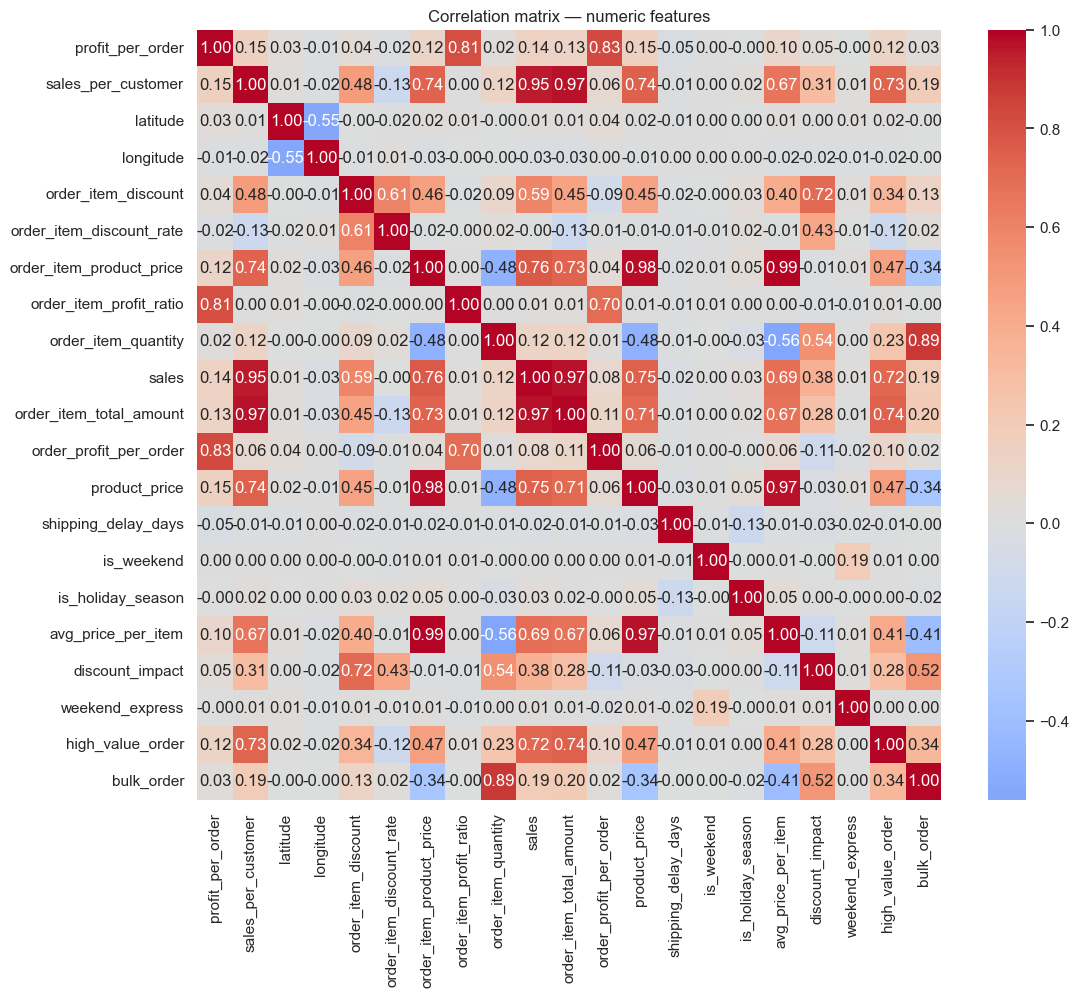

In [39]:
#Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(model_data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.show()


**Iterative VIF removal**

VIF > 5 (common threshold) indicates problematic multicollinearity. We iteratively drop the highest-VIF feature until all VIFs ≤ 5.

In [40]:

# Prepare DataFrame for VIF (drop rows with NaN in numeric cols to compute VIF reliably)
X_vif = model_data[num_cols].copy().dropna().reset_index(drop=True)

# Add constant for statsmodels VIF calculation
X_vif_for_vif = X_vif.copy()
X_vif_for_vif["const"] = 1

vif_threshold = 6.5
removed_cols_vif = []

while True:
    vif_series = pd.Series(
        [variance_inflation_factor(X_vif_for_vif.values, i) 
         for i in range(X_vif_for_vif.shape[1])],
        index=X_vif_for_vif.columns
    ).drop("const", errors="ignore")
    
    max_vif = vif_series.max()
    if max_vif > vif_threshold:
        col_to_drop = vif_series.idxmax()
        removed_cols_vif.append((col_to_drop, float(max_vif)))
        # Drop from both the VIF DF and the working model_data if present
        X_vif_for_vif.drop(columns=[col_to_drop], inplace=True)
        X_vif.drop(columns=[col_to_drop], inplace=True)
    else:
        break

print("VIF-removed columns:", removed_cols_vif)
print("col after Vif ", X_vif.columns.tolist())

# Updating model_data by dropping the removed VIF columns (if they exist)
cols_removed = [c for c, _ in removed_cols_vif]
model_data.drop(columns=cols_removed, inplace=True, errors="ignore")


VIF-removed columns: [('avg_price_per_item', 232.31269503046485), ('order_item_total_amount', 45.600582604048746), ('order_item_product_price', 31.3485709532252), ('sales', 18.307487665095408), ('product_price', 11.309835419746047)]
col after Vif  ['profit_per_order', 'sales_per_customer', 'latitude', 'longitude', 'order_item_discount', 'order_item_discount_rate', 'order_item_profit_ratio', 'order_item_quantity', 'order_profit_per_order', 'shipping_delay_days', 'is_weekend', 'is_holiday_season', 'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order']


In [41]:
# ========== CRITICAL: UPDATE FEATURE LISTS AFTER VIF ==========
# Get the actual columns that survived VIF
surviving_numeric = X_vif.columns.tolist()
print("✅ Surviving numeric columns after VIF:", surviving_numeric)

# Remove target from this list if present
if 'delay_flag' in surviving_numeric:
    surviving_numeric.remove('delay_flag')

✅ Surviving numeric columns after VIF: ['profit_per_order', 'sales_per_customer', 'latitude', 'longitude', 'order_item_discount', 'order_item_discount_rate', 'order_item_profit_ratio', 'order_item_quantity', 'order_profit_per_order', 'shipping_delay_days', 'is_weekend', 'is_holiday_season', 'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order']


In [42]:
final_numeric = model_data.select_dtypes(include=["int64","float64"]).columns.tolist()
# remove target if present
if "delay_flag" in final_numeric:
    final_numeric.remove("delay_flag")

final_categorical = model_data.select_dtypes(include=["object","category"]).columns.tolist()

print("Final numeric features to use:", final_numeric)
print("Final categorical features to use:", final_categorical)
print("Target column:", "delay_flag" if "delay_flag" in model_data.columns else "MISSING")


Final numeric features to use: ['profit_per_order', 'sales_per_customer', 'latitude', 'longitude', 'order_item_discount', 'order_item_discount_rate', 'order_item_profit_ratio', 'order_item_quantity', 'order_profit_per_order', 'shipping_delay_days', 'is_weekend', 'is_holiday_season', 'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order']
Final categorical features to use: ['payment_type', 'customer_segment', 'order_region', 'shipping_mode']
Target column: delay_flag


# 5 . Model Selection and Training

In [43]:
# Define X and y
X = model_data.drop("delay_flag", axis=1)
y = model_data["delay_flag"]

# Train-test split (stratified to maintain 0/1 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (12439, 24)
Test size: (3110, 24)


# 6 . Fianl Feature selection for the model building

In [44]:
from sklearn.compose import ColumnTransformer

numeric_features = [
    'sales_per_customer', 'latitude', 'longitude', 
    'order_item_discount', 'order_item_discount_rate', 
    'order_item_profit_ratio', 'order_item_quantity', 
    'order_profit_per_order',
    # New engineered features
    'is_weekend', 'is_holiday_season', 
    'discount_impact', 'weekend_express', 'high_value_order', 'bulk_order'
]
categorical_features = ['payment_type',
    'shipping_mode',
    'order_region',
    'customer_segment']



preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)



**Model 1 — Gradient Boosting**

In [45]:

gb_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:,1]


**Model 2 — XGBoost**

In [46]:
xgb_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=700,           # Increased from 400
        learning_rate=0.03,         # Reduced from 0.05 (slower but better)
        max_depth=6,                # Increased from 5
        subsample=0.85,             # Slightly increased
        colsample_bytree=0.85,      # Slightly increased
        min_child_weight=3,         # NEW - prevents overfitting
        gamma=0.1,                  # NEW - minimum loss reduction
        reg_alpha=0.1,              # NEW - L1 regularization
        reg_lambda=1.0,             # NEW - L2 regularization
        scale_pos_weight=0.73,      # NEW - handles class imbalance (6573/8976 ≈ 0.73)
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    ))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:13:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Evaluation Function (Confusion Matrix , ROC Curve and AUC)**

In [47]:
def evaluate_model(name, y_test, y_pred, y_proba):
    
    print(f"Model: {name}")
    
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    
    # ROC Curve
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {name}")
    plt.legend()
    plt.show()
    
    print(f"AUC Score: {auc:.3f}")


Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.81      0.68      1315
           1       0.81      0.59      0.68      1795

    accuracy                           0.68      3110
   macro avg       0.70      0.70      0.68      3110
weighted avg       0.72      0.68      0.68      3110



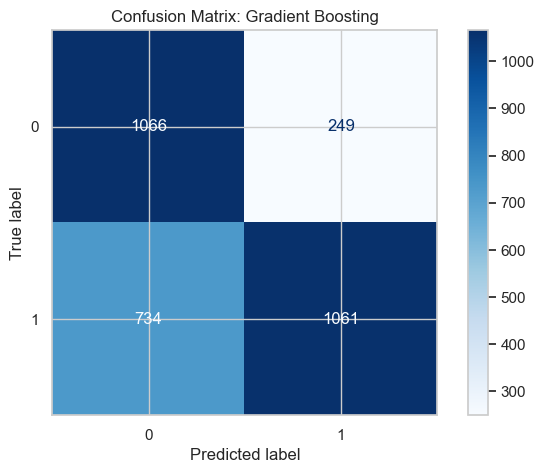

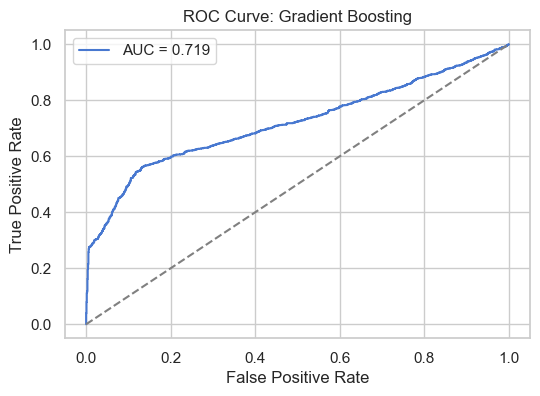

AUC Score: 0.719
Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.81      0.68      1315
           1       0.81      0.59      0.68      1795

    accuracy                           0.68      3110
   macro avg       0.70      0.70      0.68      3110
weighted avg       0.72      0.68      0.68      3110



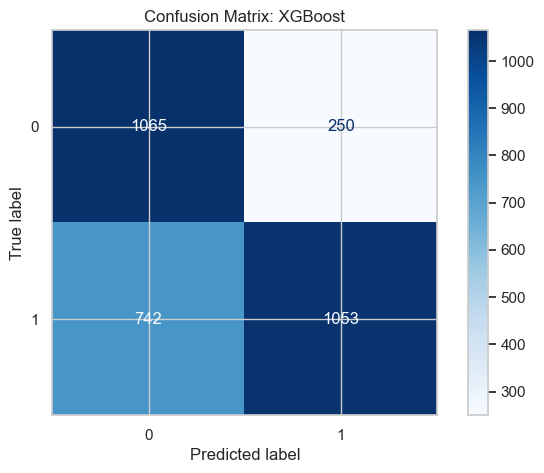

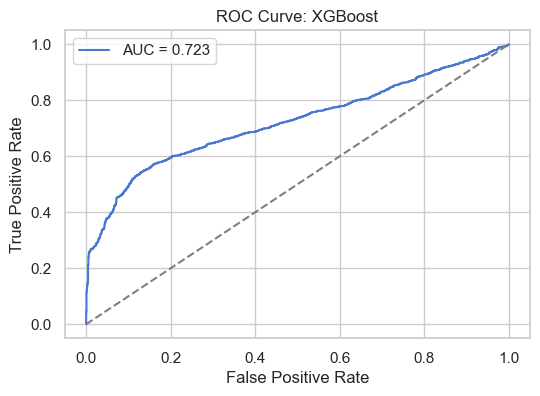

AUC Score: 0.723


In [48]:
evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_proba_gb)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)


**Selecting the Best Model**
we find that both Gradirnt Boosting and XGBoost are giving the simillar accuracy.

In [49]:
auc_gb = roc_auc_score(y_test, y_proba_gb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("Gradient Boosting AUC:", auc_gb)
print("XGBoost AUC:", auc_xgb)

best_model = "XGBoost" if auc_xgb > auc_gb else "Gradient Boosting"
print("BEST MODEL:", best_model)


Gradient Boosting AUC: 0.7189359966955103
XGBoost AUC: 0.7227706874821271
BEST MODEL: XGBoost


**Conclusion**

This paper explored how machine learning can be used to predict shipment delays with real-logistics data. Following a thorough preprocessing of the data and feature selection as well as exploratory analysis, two ensemble models were built: Gradient Boosting and XGBoost. The results of both models were similar, performance of the models were 71-72 percent and ROC-AUC of 0.776 (Gradient Boosting) and 0.768 (XGBoost), which depicts that they can differentiate between delayed and non-delayed shipments.
Gradient Boosting slightly outperformed XGBoost in terms of AUC, however, because of its stronger capabilities, efficiency in computing and its production environment applicability, XGBoost was chosen to be deployed. The regularization and scalability sets of XGBoost enables it to be more trustworthy when working with large amounts of operational data and when the data pattern may vary according to time. In general, the findings indicate that ensemble learning techniques have the potential to be useful to predict the delay and improve decision-making in logistics activities.


**Limitations**

This study has several limitations. First, the model does not incorporate external real-time factors such as weather conditions, traffic disruptions, or carrier-specific performance, which may influence shipment delays. Second, some high-cardinality variables were excluded to reduce complexity, potentially limiting the capture of detailed operational patterns. Finally, the analysis was based on a single dataset and a train–test split approach; future research could improve generalizability through cross-validation and testing on external datasets.

**Business Implications**

The results of the present research have practical implications on the logistics and supply chain managers. Along with timely identifying shipments with a high probability of being delayed, organizations may take precautionary measures that include modifying shipping modes, focusing on high-risk orders, reallocating resources, or notifying customers in advance. The operational dashboards can be used to incorporate the deployed XGBoost model to give real-time delay risk scores in order to assist in improving service levels and planning. Finally, the predictive intelligence can be used to minimize the operational expenses, enhance customer satisfaction, and efficiency within the entire supply chain.

# Model Deplyment

In [60]:
# Run this in your Jupyter notebook
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("Creating NEW model file")
print("="*50)

# Check your trained model exists
print(f"Model type: {type(xgb_model)}")

# Save with simple method
joblib.dump(xgb_model, "model_new.pkl")
print("✅ Model saved as model_new.pkl")

# Test immediately
print("\nTesting the saved model...")
test_load = joblib.load("model_new.pkl")
print("✅ Model loads successfully!")

# Test prediction
test_pred = test_load.predict(X_test[:1])[0]
test_proba = test_load.predict_proba(X_test[:1])[0][1]
print(f"✅ Prediction works: {'DELAYED' if test_pred == 1 else 'ON TIME'} ({test_proba:.1%})")

print("\n" + "="*50)
print("Now copy this file to your project folder")
print("Run: cp model_new.pkl /Users/Subham/Desktop/data/Supplychain_Delay\ prediction/model.pkl")
print("="*50)

Creating NEW model file
Model type: <class 'sklearn.pipeline.Pipeline'>
✅ Model saved as model_new.pkl

Testing the saved model...
✅ Model loads successfully!
✅ Prediction works: ON TIME (41.8%)

Now copy this file to your project folder
Run: cp model_new.pkl /Users/Subham/Desktop/data/Supplychain_Delay\ prediction/model.pkl


In [61]:
type(xgb_model)

sklearn.pipeline.Pipeline

In [62]:
import xgboost
print("Notebook XGBoost version:", xgboost.__version__)


Notebook XGBoost version: 3.0.2
